## Month 2 Week 4

### Statistics , Probability and Exploratory Analysis (EDA)


In [1]:
# import ssl
# import certifi
# ssl.get_default_verify_paths()  # check what's being used
# ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Make chart look nice
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (9,5)

dataset_names = sns.get_dataset_names()     #  This gets the dataset names
print(dataset_names)

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [4]:
# df = sns.load_dataset('titanic')
df = pd.read_csv('Titanic-Dataset.csv')

In [5]:
print(f'Dateset Shape: {df.shape[0]} row , {df.shape[1]} column')# it lets you information about the rows and column

Dateset Shape: 891 row , 12 column


In [6]:
df.head(10) # take a peek at the data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


# Column guide

| Column     | Meaning                                                              |
|------------|----------------------------------------------------------------------|
| `Survived` | Did the passenger survive? (0 = No, 1 = Yes                          |
| `pclass`   | Passenger Class (1 = 1st/luxury, 2 = 2nd, 3 = 3rd/cheapest           |
| `sex`      | Gender                                                               |
| `age`      | Age in years                                                         |
| `sibsp`    | Number of siblings/spouse aboard                                     |
| `parch`    | Number of parents/children aboard                                    |
| `fare`     | Ticket price paid (in 1912 British Pound                             |
| `embarked` | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |





In [8]:
df['Survived'].value_counts()
# df['Sex'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [9]:
age = df['Age']

In [10]:
mean_age = round(df['Age'].mean(),1)
print(mean_age)

29.7


In [11]:
median_age = df['Age'].median()
print(median_age)

28.0


In [12]:
modal_age = df['Age'].mode()[0]
# print(modal_age)

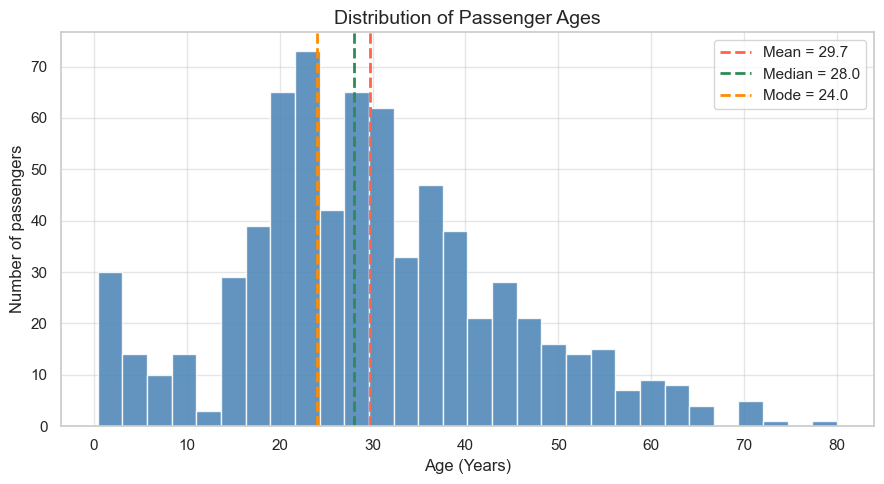

In [13]:
# Measure of center

fig, ax = plt.subplots()

ax.hist(age, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(mean_age, color='tomato', linestyle='--', linewidth=2, label=f'Mean = {mean_age:.1f}')
ax.axvline(median_age, color='seagreen', linestyle='--', linewidth=2, label=f'Median = {median_age:.1f}')
ax.axvline(modal_age, color='darkorange', linestyle='--', linewidth=2, label=f'Mode = {modal_age:.1f}')

ax.set_title('Distribution of Passenger Ages', fontsize=14)
ax.set_xlabel('Age (Years)')
ax.set_ylabel('Number of passengers')
ax.legend()
plt.tight_layout()
plt.show()



In [14]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Measure of spread
Range, Variance, Std, IQR

- Range
It is the difference between the minimum and maximum, it is sensitive to outliers

- Standard Deviation
It is the square root of the variance

- Variance
It is a number that tells us how spread apart our distribution is from the mean

- IQR (Inter Quartile Range)
 is another measure of spread, but unlike variance it focuses on the middle 50% of the data.


<Axes: >

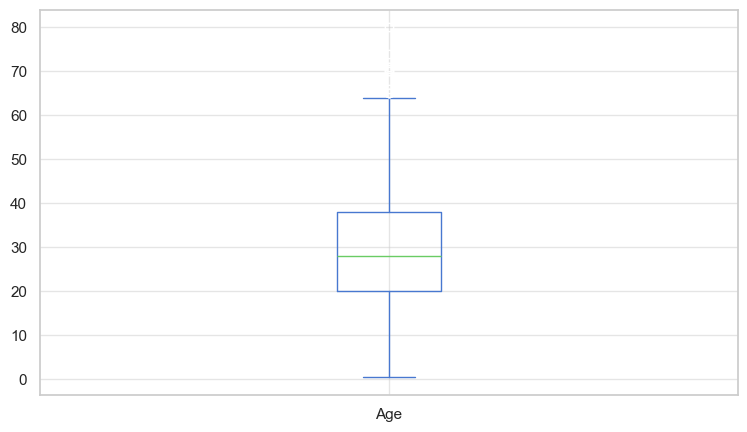

In [15]:
df['Age'].plot(kind='box')

## Probability

If probability is 0 = not possible

If probability is 1 = very possible


In [16]:
total = len(df)
survived = df['Survived'].sum()

p_survived = survived/total
print(p_survived)

0.3838383838383838


In [19]:
female = df[df['Sex'] == 'female']

In [20]:
female['Survived'].mean()

np.float64(0.7420382165605095)

In [22]:
male = df[df['Sex'] == 'male']
male['Survived'].mean()

np.float64(0.18890814558058924)

In [ ]:
# TODO : Check for other class